In [1]:
!python3 --version
!python3 -m pip install tensorflow pandas numpy scikit-learn matplotlib

Python 3.13.12
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical
from keras.optimizers import Adam

In [3]:
train = "final.csv"
test = "test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

In [4]:
X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:

def build_cnn(input_shape, num_classes):
    model = Sequential([
        
        Conv1D(64, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        
        Conv1D(256, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Replace Flatten with GAP
        GlobalAveragePooling1D(),

        # Dense head
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(X, y_encoded):
    print(f"\nFold {fold}/10")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)

    model = build_cnn(
        input_shape=(X.shape[1], 1),
        num_classes=num_classes
    )

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=75,
        batch_size=256,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    fold_accuracies.append(val_acc)
    histories.append(history)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1


Fold 1/10
Epoch 1/75


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7463 - loss: 0.6240 - val_accuracy: 0.5548 - val_loss: 2.1561
Epoch 2/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8206 - loss: 0.4312 - val_accuracy: 0.5409 - val_loss: 1.3429
Epoch 3/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8575 - loss: 0.3521 - val_accuracy: 0.8637 - val_loss: 0.3486
Epoch 4/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8713 - loss: 0.3202 - val_accuracy: 0.8730 - val_loss: 0.2995
Epoch 5/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8745 - loss: 0.3132 - val_accuracy: 0.6541 - val_loss: 1.7675
Epoch 6/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8828 - loss: 0.2951 - val_accuracy: 0.7910 - val_loss: 0.3823
Epoch 7/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8831 - loss: 0.2941 - val_accuracy: 0.5758 - val_loss: 11.1572
Epoch 8/75
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8910 - loss: 0.2794 - val_accuracy: 0.72

In [9]:
print("\nCross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Dev: {np.std(fold_accuracies):.4f}")


Cross-Validation Results
Mean Accuracy: 0.8192
Std Dev: 0.0694


In [10]:
y_cat = to_categorical(y_encoded, num_classes)

final_model = build_cnn(
    input_shape=(X.shape[1], 1),
    num_classes=num_classes
)

final_history = final_model.fit(
    X,
    y_cat,
    epochs=75,
    batch_size=256,
    verbose=1
)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7624 - loss: 0.5778
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8388 - loss: 0.3903
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8644 - loss: 0.3300
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8681 - loss: 0.3250
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8866 - loss: 0.2826
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8893 - loss: 0.2798
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8960 - loss: 0.2636
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9007 - loss: 0.2528
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9037 - loss: 0.2473
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9068 - loss: 0.2395
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9060 - loss: 0.2406
Epoch 12/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
y_test_cat = to_categorical(y_test_encoded, num_classes)

test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nBest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Best Accuracy: 0.9607
Test Loss: 0.6387


581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1200x1200 with 0 Axes>

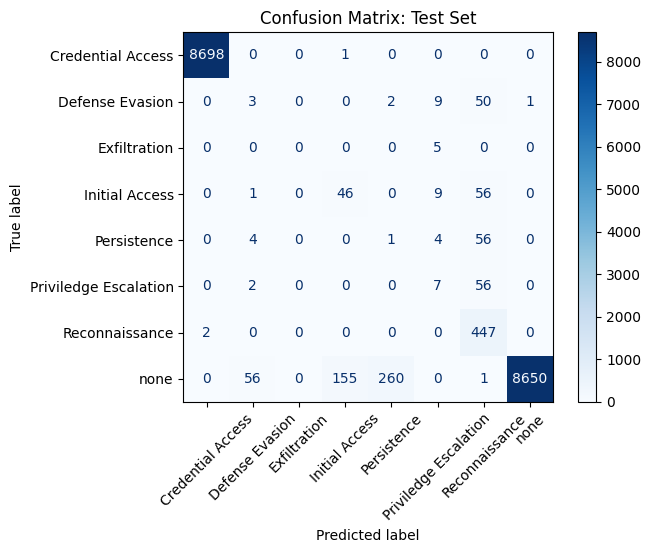

In [12]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix: Test Set")
plt.show()

581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report
                       precision    recall  f1-score   support

    Credential Access       1.00      1.00      1.00      8699
      Defense Evasion       0.05      0.05      0.05        65
         Exfiltration       0.00      0.00      0.00         5
       Initial Access       0.23      0.41      0.29       112
          Persistence       0.00      0.02      0.01        65
Priviledge Escalation       0.21      0.11      0.14        65
       Reconnaissance       0.67      1.00      0.80       449
                 none       1.00      0.95      0.97      9122

             accuracy                           0.96     18582
            macro avg       0.39      0.44      0.41     18582
         weighted avg       0.98      0.96      0.97     18582



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

<Figure size 1200x1200 with 0 Axes>

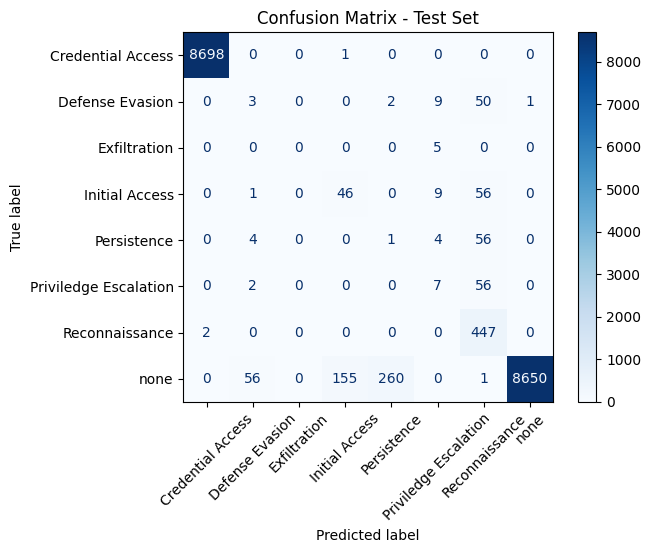


False Positive Rate (per class)
Credential Access: 0.0002
Defense Evasion: 0.0034
Exfiltration: 0.0000
Initial Access: 0.0084
Persistence: 0.0141
Priviledge Escalation: 0.0015
Reconnaissance: 0.0121
none: 0.0001

Average FPR: 0.004980148935335023


In [13]:

y_test_pred = np.argmax(final_model.predict(X_test), axis=1)


print("\nClassification Report")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))

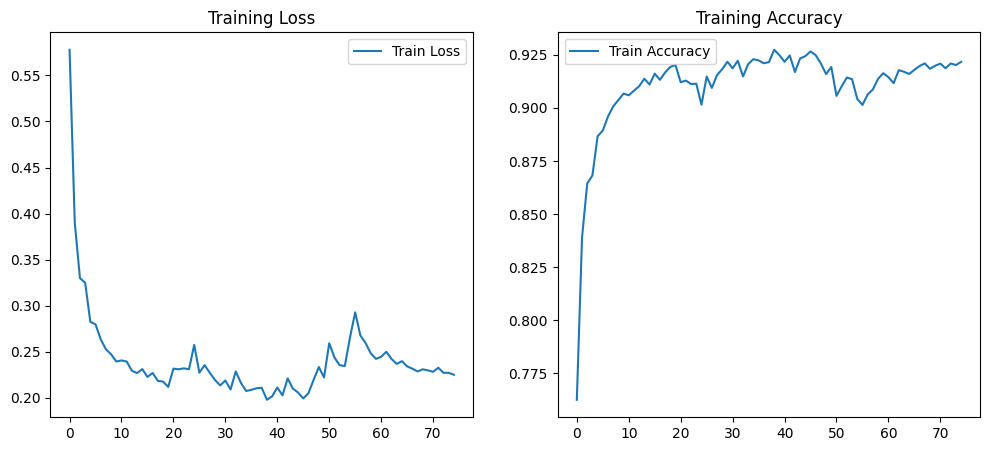

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()